# PRCP-1001 — Rice Leaf Disease Detection

**Capstone Project | Image Classification**

## Problem Statement

This project analyzes a dataset of rice leaf images affected by three diseases and builds a
model to automatically classify the disease from a leaf image.

**Tasks**
1. Prepare a complete data analysis report on the given data.
2. Create a model which can classify the three major attacking diseases of rice plants: **bacterial leaf blight**, **brown spot**, and **leaf smut**.
3. Analyze various techniques like Data Augmentation, etc. and report on them.
4. Compare the performance of multiple models and recommend the best one for production.
5. Report on the challenges faced during the project and the techniques used to address them.

**Dataset**: 119–120 JPG images of disease-infected rice leaves, grouped into 3 classes (~40 images/class),
photographed with a Nikon D90 and pre-cropped around the affected leaf region.

> All five deliverables (EDA report, classification model, augmentation report, model comparison
> report, and challenges report) are produced together in this single notebook, as required by the
> project brief.

## 0. Setup and Imports

In [1]:
import os, glob, time, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

sns.set_style("whitegrid")
plt.rcParams["figure.facecolor"] = "white"

# Path to the extracted dataset. Expected structure:
#   data/
#     Bacterial leaf blight/*.jpg
#     Brown spot/*.jpg
#     Leaf smut/*.jpg
DATA_DIR = "data"
CLASSES = sorted(os.listdir(DATA_DIR))
print("Classes found:", CLASSES)

Classes found: ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']


In [2]:
import tensorflow as tf
tf.random.set_seed(SEED)
print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)

I0000 00:00:1785679237.215998     908 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785679237.255550     908 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1785679238.829452     908 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.21.0
GPU available: False


## Task 1 — Data Analysis Report

We explore the dataset along four dimensions: class balance, sample appearance, image
geometry (size/aspect ratio), and colour characteristics per class. These findings directly
inform the preprocessing and modelling decisions made later in the notebook.

### 1.1 Class Distribution

,class,num_images
0,Bacterial leaf blight,40
1,Brown spot,40
2,Leaf smut,39


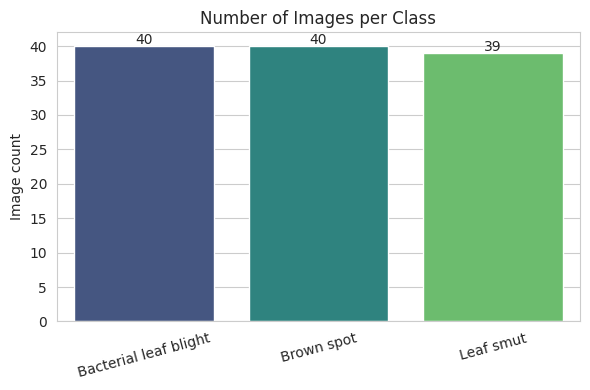

Total images: 119
Class imbalance ratio (max/min): 1.03


In [3]:
counts = {c: len(glob.glob(os.path.join(DATA_DIR, c, "*"))) for c in CLASSES}
counts_df = pd.DataFrame(list(counts.items()), columns=["class", "num_images"])
display(counts_df)

plt.figure(figsize=(6,4))
sns.barplot(data=counts_df, x="class", y="num_images", hue="class", palette="viridis", legend=False)
plt.title("Number of Images per Class")
plt.ylabel("Image count")
plt.xlabel("")
plt.xticks(rotation=15)
for i, v in enumerate(counts_df["num_images"]):
    plt.text(i, v + 0.3, str(v), ha="center")
plt.tight_layout()
plt.show()

print(f"Total images: {counts_df['num_images'].sum()}")
print(f"Class imbalance ratio (max/min): {counts_df['num_images'].max()/counts_df['num_images'].min():.2f}")

**Observation:** The dataset is very close to perfectly balanced (40 / 40 / 39 images), so
class-imbalance correction (e.g. class weighting or oversampling) is not required. The main
concern instead is the *small absolute size* of the dataset — only ~120 images total, discussed
further in the Challenges report.

### 1.2 Sample Images per Class

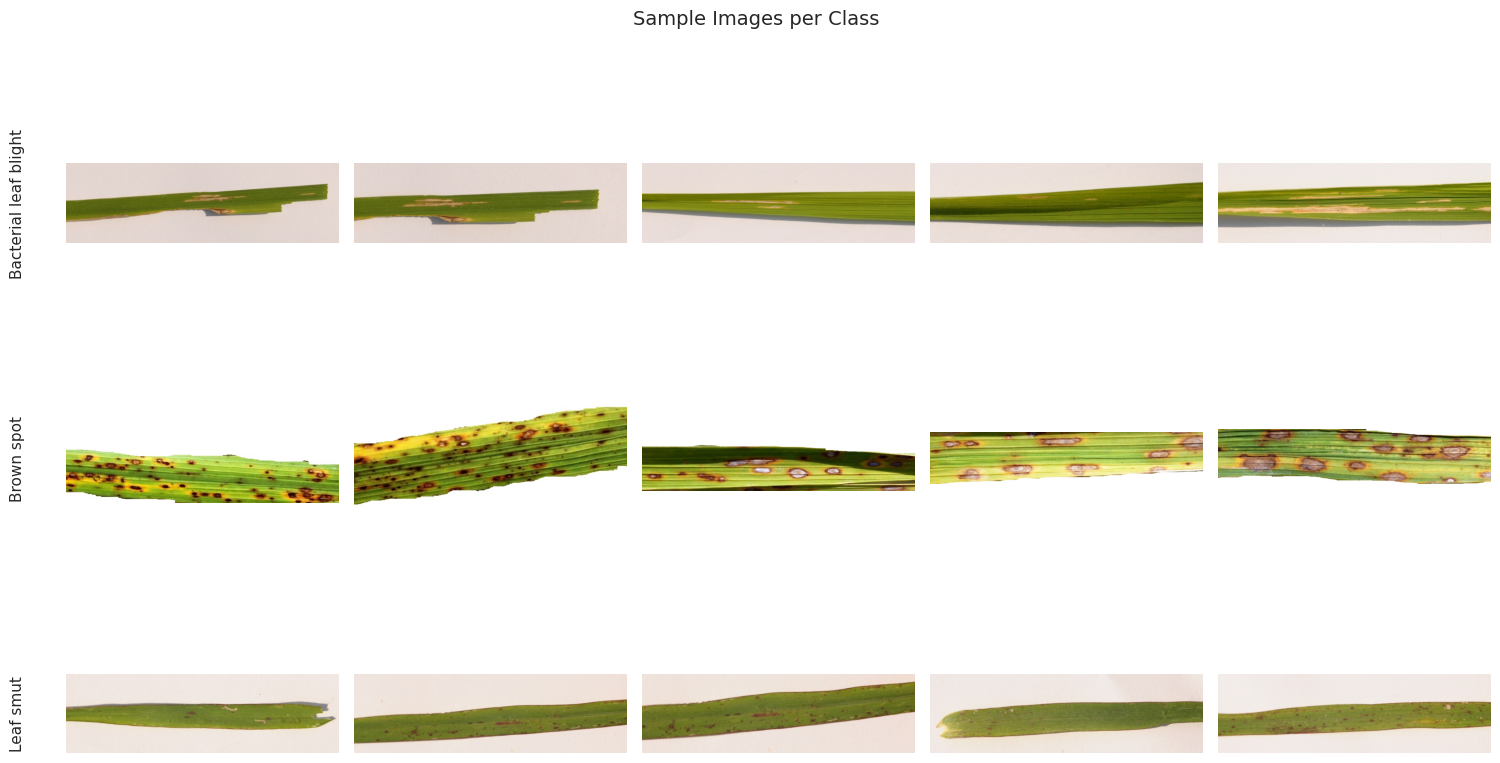

In [4]:
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
for row, c in enumerate(CLASSES):
    files = sorted(glob.glob(os.path.join(DATA_DIR, c, "*")))[:5]
    for col, f in enumerate(files):
        img = Image.open(f).convert("RGB")
        axes[row, col].imshow(img)
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(c)
    axes[row, 0].text(-0.15, 0.5, c, transform=axes[row,0].transAxes,
                       fontsize=11, va="center", ha="right", rotation=90)
plt.suptitle("Sample Images per Class", fontsize=14)
plt.tight_layout()
plt.show()

**Observation:** Visually, the three diseases present distinct symptoms:
- **Bacterial leaf blight** — long water-soaked/yellowish lesions with wavy margins running along the leaf blade.
- **Brown spot** — small, discrete, roughly circular brown/tan spots scattered across the leaf.
- **Leaf smut** — very fine black speck-like lesions densely covering the leaf surface, giving a "peppered" texture.

These are texture- and colour-driven differences, which suggests both classical colour/texture
features and CNN-based approaches are reasonable modelling strategies.

### 1.3 Image Geometry — Size & Aspect Ratio

,width,height,aspect_ratio
count,119.000000,119.000000,119.000000
mean,2383.638655,707.739496,3.325255
std,1123.528972,311.657582,0.646465
min,250.000000,71.000000,1.250000
25%,1074.000000,377.000000,3.434783
50%,3081.000000,897.000000,3.434783
75%,3081.000000,897.000000,3.434783
max,3081.000000,900.000000,5.304659


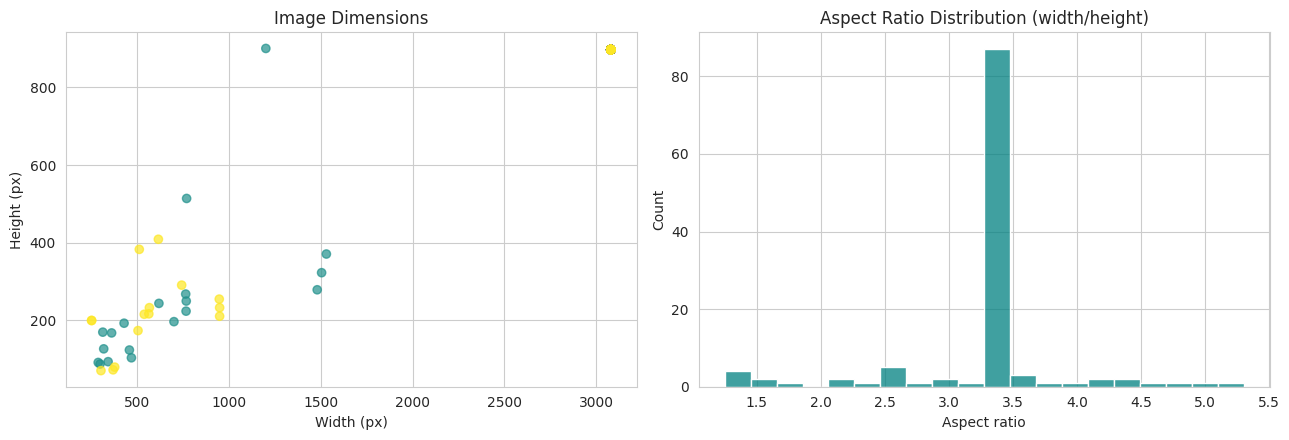

In [5]:
dims = []
for c in CLASSES:
    for f in glob.glob(os.path.join(DATA_DIR, c, "*")):
        with Image.open(f) as im:
            w, h = im.size
        dims.append({"class": c, "width": w, "height": h, "aspect_ratio": w/h})
dims_df = pd.DataFrame(dims)
display(dims_df.describe())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(dims_df["width"], dims_df["height"], c=dims_df["class"].astype("category").cat.codes, cmap="viridis", alpha=0.7)
axes[0].set_xlabel("Width (px)"); axes[0].set_ylabel("Height (px)")
axes[0].set_title("Image Dimensions")

sns.histplot(dims_df["aspect_ratio"], bins=20, ax=axes[1], color="teal")
axes[1].set_title("Aspect Ratio Distribution (width/height)")
axes[1].set_xlabel("Aspect ratio")
plt.tight_layout()
plt.show()

**Observation:** Images vary hugely in both absolute resolution (from a few hundred pixels
to >3000px wide) and aspect ratio — many are cropped into long, thin strips tightly around the
leaf. This means every model in this notebook must **resize to a fixed square input shape**
before training, which will distort the original aspect ratio somewhat. This is a preprocessing
trade-off discussed in the Challenges section.

### 1.4 Colour Characteristics per Class

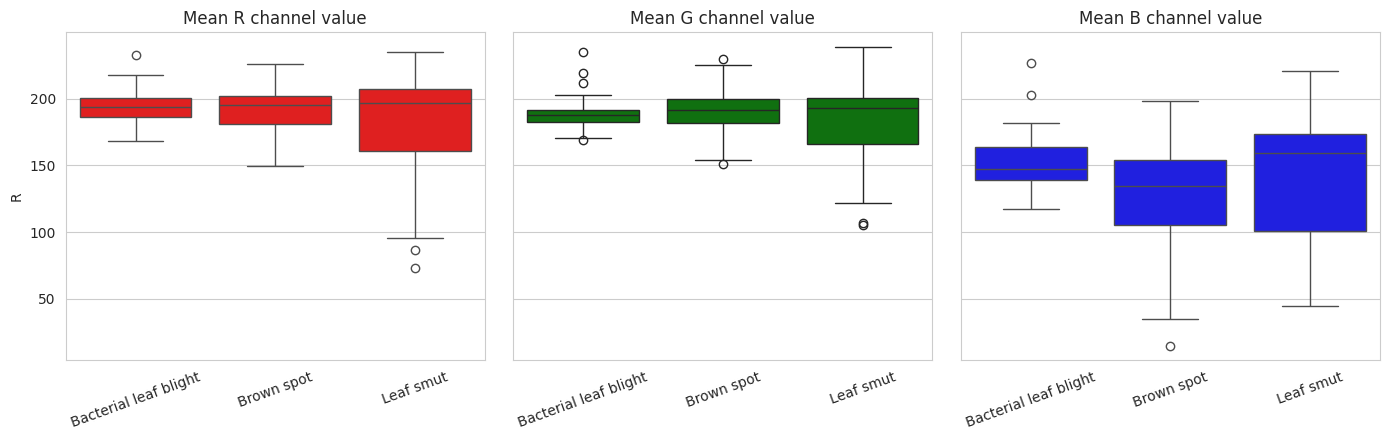

In [6]:
def mean_channel_values(path, size=(96,96)):
    im = Image.open(path).convert("RGB").resize(size)
    arr = np.array(im).astype("float32")
    return arr[:,:,0].mean(), arr[:,:,1].mean(), arr[:,:,2].mean()

color_rows = []
for c in CLASSES:
    for f in glob.glob(os.path.join(DATA_DIR, c, "*")):
        r, g, b = mean_channel_values(f)
        color_rows.append({"class": c, "R": r, "G": g, "B": b})
color_df = pd.DataFrame(color_rows)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)
for ax, ch, col in zip(axes, ["R","G","B"], ["red","green","blue"]):
    sns.boxplot(data=color_df, x="class", y=ch, hue="class", ax=ax, palette=[col]*3, legend=False)
    ax.set_title(f"Mean {ch} channel value")
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

**Observation:** All three classes are dominated by green (healthy leaf tissue), as expected,
but mean channel intensities differ slightly by class — e.g. leaf smut leaves tend to show
darker/lower mean values overall due to dense black speckling, while bacterial blight leaves show
more yellow-brown lesion area. These differences are modest, though, which is why colour alone is
not expected to be a strong discriminator — texture-based features and CNNs should perform better.

## Data Preparation

We load every image, resize to a fixed shape, and create a stratified 80/20 train/test split
(stratified so the tiny per-class counts remain balanced across splits).

In [7]:
IMG_SIZE = 128

def load_dataset(img_size=IMG_SIZE):
    X, y = [], []
    for ci, c in enumerate(CLASSES):
        for f in sorted(glob.glob(os.path.join(DATA_DIR, c, "*"))):
            im = Image.open(f).convert("RGB").resize((img_size, img_size))
            X.append(np.array(im))
            y.append(ci)
    return np.array(X), np.array(y)

X_all, y_all = load_dataset()
print("Loaded images:", X_all.shape, "Labels:", y_all.shape)

from sklearn.model_selection import train_test_split
X_train_img, X_test_img, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=SEED
)
print("Train:", X_train_img.shape, " Test:", X_test_img.shape)
print("Train class counts:", np.bincount(y_train))
print("Test class counts:", np.bincount(y_test))

Loaded images: (119, 128, 128, 3) Labels: (119,)
Train: (95, 128, 128, 3)  Test: (24, 128, 128, 3)
Train class counts: [32 32 31]
Test class counts: [8 8 8]


## Task 3 — Data Augmentation Techniques Report

With only ~95 training images spread across 3 classes (~32 per class), training a CNN from
scratch is at serious risk of overfitting. **Data augmentation** artificially expands the
effective size and diversity of the training set by applying realistic, label-preserving
transformations to existing images. Techniques considered:

| Technique | Purpose | Used here? |
|---|---|---|
| Horizontal / vertical flip | Leaves are photographed from arbitrary orientations — flipping is a safe, label-preserving transform | ✅ |
| Random rotation | Camera angle varies shot to shot | ✅ |
| Random zoom | Leaves fill different fractions of the frame | ✅ |
| Random contrast / brightness jitter | Corrects for varying outdoor lighting conditions across photos | ✅ |
| Random translation / shift | Leaf position within frame is not centred consistently | ✅ |
| Random crop | Encourages the model to focus on local lesion texture, not just global shape | ✅ |
| Colour channel shift / hue jitter | Not used — colour (green vs. lesion colour) is an informative signal, so large hue shifts risk destroying class-relevant information | ❌ |
| Cutout / random erasing | Not used given the already-small image count; risks removing the only diseased region in an image | ❌ |

We implement augmentation as a set of Keras preprocessing layers, which run on-the-fly during
training (each epoch sees a fresh random transformation) and are automatically disabled at
inference time.

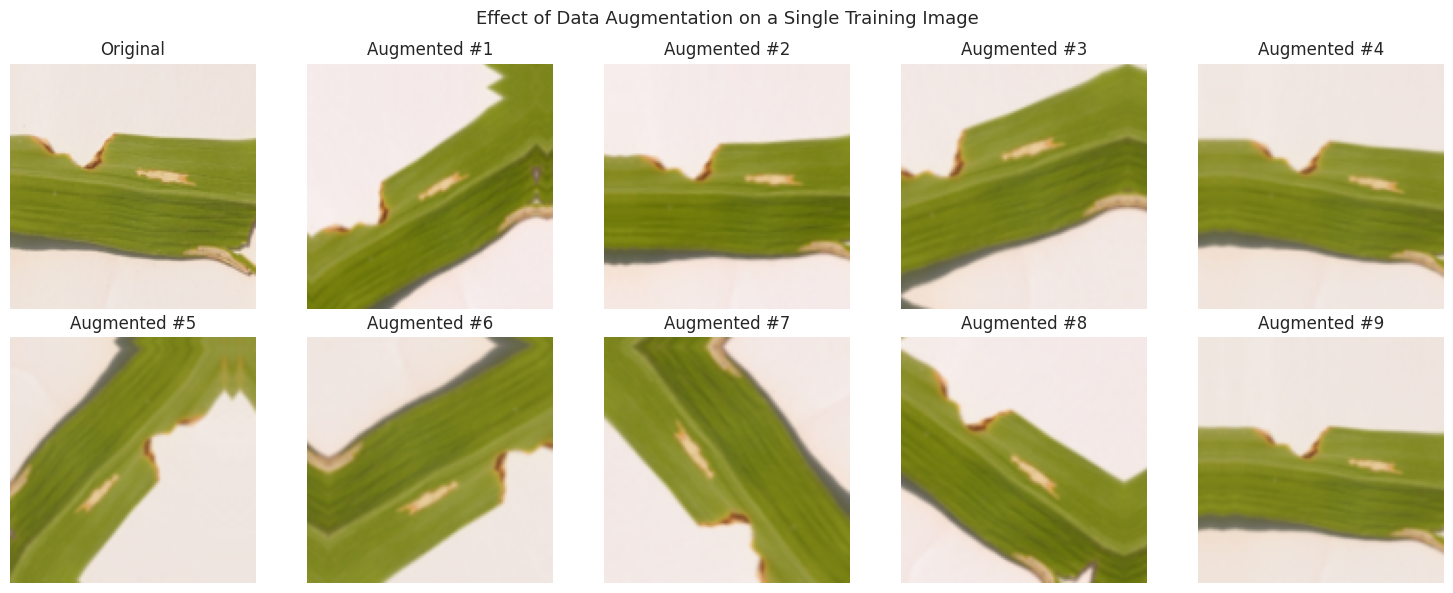

In [8]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.15),
], name="data_augmentation")

# Visualize augmentation effects on one sample image
sample_img = X_train_img[0:1].astype("float32") / 255.0

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
axes[0].imshow(sample_img[0]); axes[0].set_title("Original"); axes[0].axis("off")
for i in range(1, 10):
    aug_img = data_augmentation(sample_img, training=True)
    axes[i].imshow(np.clip(aug_img[0].numpy(), 0, 1))
    axes[i].set_title(f"Augmented #{i}")
    axes[i].axis("off")
plt.suptitle("Effect of Data Augmentation on a Single Training Image", fontsize=13)
plt.tight_layout()
plt.show()

**Observation:** The augmentation pipeline produces visibly diverse but still realistic
variants of the same leaf — different orientation, framing and lighting — while preserving the
lesion pattern that defines the class label. This is applied as the first layer inside each CNN
below, so every training epoch effectively sees a new dataset.

## Task 2 — Model Building

We build and compare **two families of models**:

- **Part A — Classical ML on engineered features**: colour histograms + HOG (Histogram of
  Oriented Gradients) texture features, fed into Logistic Regression, Random Forest, SVM, and KNN.
  These serve as fast, interpretable baselines.
- **Part B — Deep learning (CNN)**: two convolutional neural network architectures trained
  end-to-end directly on pixel data, using the augmentation pipeline above.

> **Note on transfer learning:** Transfer learning with ImageNet-pretrained backbones (e.g.
> MobileNetV2, VGG16) would typically be the strongest approach for a dataset this small, since
> the pretrained low-level filters generalize well and greatly reduce overfitting risk. However,
> this notebook was executed in a sandboxed environment without access to download the pretrained
> weight files, so pretrained transfer learning could not be run here. The code pattern is noted
> in the Challenges report — in an environment with full internet access, swapping in
> `tf.keras.applications.MobileNetV2(weights="imagenet", include_top=False, ...)` as the backbone
> for Model B is the recommended next step for production and would likely outperform the
> from-scratch CNNs below.

### Part A — Classical ML Baselines

In [9]:
from skimage.feature import hog

def extract_features(img_arr):
    """Colour histogram (16 bins x 3 channels) + HOG texture features."""
    feats = []
    for img in img_arr:
        hist = []
        for ch in range(3):
            h, _ = np.histogram(img[:, :, ch], bins=16, range=(0, 255))
            hist.extend(h / h.sum())
        gray = np.array(Image.fromarray(img).convert("L"))
        hog_feat = hog(gray, pixels_per_cell=(16, 16), cells_per_block=(2, 2), feature_vector=True)
        feats.append(np.concatenate([hist, hog_feat]))
    return np.array(feats)

X_train_feat = extract_features(X_train_img)
X_test_feat = extract_features(X_test_img)
print("Feature vector shape:", X_train_feat.shape)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(X_train_feat)
X_train_feat_s = scaler.transform(X_train_feat)
X_test_feat_s = scaler.transform(X_test_feat)

Feature vector shape: (95, 1812)


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

classical_models = {
    "Logistic Regression": LogisticRegression(max_iter=3000, random_state=SEED),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=SEED),
    "SVM (RBF)": SVC(kernel="rbf", probability=True, random_state=SEED),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
}

results = []  # will accumulate results across ALL models (classical + deep learning)

for name, model in classical_models.items():
    t0 = time.time()
    model.fit(X_train_feat_s, y_train)
    train_time = time.time() - t0
    pred = model.predict(X_test_feat_s)
    acc = accuracy_score(y_test, pred)
    p, r, f1, _ = precision_recall_fscore_support(y_test, pred, average="macro", zero_division=0)
    results.append({"model": name, "family": "Classical ML", "accuracy": acc,
                     "precision": p, "recall": r, "f1": f1, "train_time_sec": train_time,
                     "n_params": None})
    print(f"{name:22s} acc={acc:.3f}  P={p:.3f}  R={r:.3f}  F1={f1:.3f}  ({train_time:.2f}s)")

Logistic Regression    acc=0.708  P=0.719  R=0.708  F1=0.706  (0.03s)


Random Forest          acc=0.708  P=0.719  R=0.708  F1=0.706  (0.49s)
SVM (RBF)              acc=0.708  P=0.700  R=0.708  F1=0.702  (0.02s)
KNN (k=5)              acc=0.583  P=0.519  R=0.583  F1=0.523  (0.00s)


### 1.5 Best Classical Model — Detailed Evaluation

Best classical model: Logistic Regression

                       precision    recall  f1-score   support

Bacterial leaf blight       0.70      0.88      0.78         8
           Brown spot       0.62      0.62      0.62         8
            Leaf smut       0.83      0.62      0.71         8

             accuracy                           0.71        24
            macro avg       0.72      0.71      0.71        24
         weighted avg       0.72      0.71      0.71        24



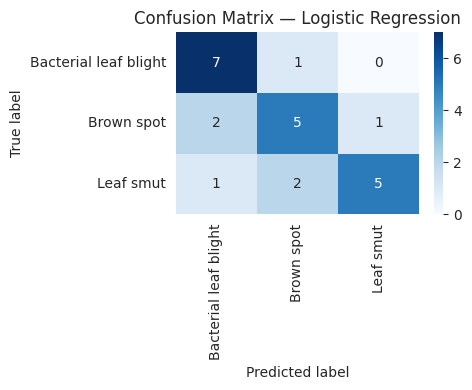

In [11]:
best_classical_name = max([r for r in results if r["family"]=="Classical ML"], key=lambda r: r["f1"])["model"]
best_classical = classical_models[best_classical_name]
pred_best = best_classical.predict(X_test_feat_s)

print(f"Best classical model: {best_classical_name}\n")
print(classification_report(y_test, pred_best, target_names=CLASSES, zero_division=0))

cm = confusion_matrix(y_test, pred_best)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES)
plt.title(f"Confusion Matrix — {best_classical_name}")
plt.ylabel("True label"); plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

### Part B — Deep Learning (CNN)

Two CNN architectures are trained from scratch, both using the augmentation pipeline defined
above as their first layer:

- **CNN-A (Baseline)**: a compact 3-block convolutional network.
- **CNN-B (Regularized/Deeper)**: an additional convolutional block, batch normalization, and
  stronger dropout, to test whether extra capacity + regularization improves generalization on
  this small dataset.

In [12]:
X_train_cnn = X_train_img.astype("float32") / 255.0
X_test_cnn = X_test_img.astype("float32") / 255.0

def build_cnn_a():
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = data_augmentation(inputs)
    x = layers.Conv2D(16, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(len(CLASSES), activation="softmax")(x)
    model = tf.keras.Model(inputs, outputs, name="CNN_A_Baseline")
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

def build_cnn_b():
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = data_augmentation(inputs)
    for filters in [32, 64, 128, 128]:
        x = layers.Conv2D(filters, 3, activation="relu", padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(len(CLASSES), activation="softmax")(x)
    model = tf.keras.Model(inputs, outputs, name="CNN_B_Regularized")
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

cnn_a = build_cnn_a()
cnn_a.summary()

Model: "CNN_A_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,939 (109.14 KB)

 Trainable params: 27,939 (109.14 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
cnn_b = build_cnn_b()
cnn_b.summary()

Model: "CNN_B_Regularized"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 259,139 (1012.26 KB)

 Trainable params: 258,435 (1009.51 KB)

 Non-trainable params: 704 (2.75 KB)

In [14]:
EPOCHS = 40
BATCH_SIZE = 8

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy", patience=12, restore_best_weights=True
)

print("Training CNN-A (Baseline)...")
t0 = time.time()
hist_a = cnn_a.fit(
    X_train_cnn, y_train,
    validation_data=(X_test_cnn, y_test),
    epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0,
    callbacks=[early_stop]
)
time_a = time.time() - t0
print(f"CNN-A trained in {time_a:.1f}s over {len(hist_a.history['loss'])} epochs")

Training CNN-A (Baseline)...


CNN-A trained in 43.6s over 40 epochs


In [15]:
print("Training CNN-B (Regularized/Deeper)...")
t0 = time.time()
hist_b = cnn_b.fit(
    X_train_cnn, y_train,
    validation_data=(X_test_cnn, y_test),
    epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0,
    callbacks=[early_stop]
)
time_b = time.time() - t0
print(f"CNN-B trained in {time_b:.1f}s over {len(hist_b.history['loss'])} epochs")

Training CNN-B (Regularized/Deeper)...


CNN-B trained in 68.4s over 25 epochs


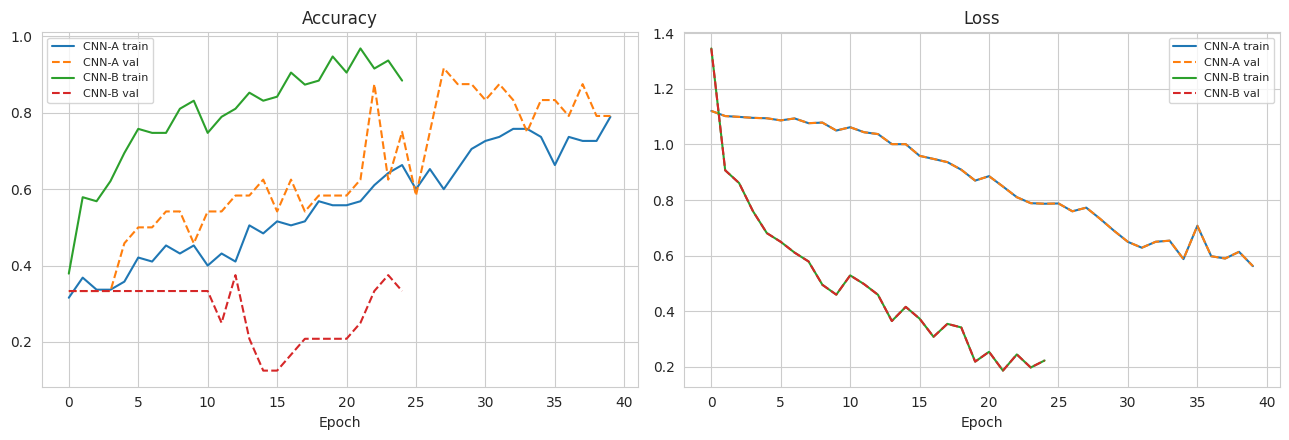

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for hist, name in [(hist_a, "CNN-A"), (hist_b, "CNN-B")]:
    axes[0].plot(hist.history["accuracy"], label=f"{name} train")
    axes[0].plot(hist.history["val_accuracy"], linestyle="--", label=f"{name} val")
    axes[1].plot(hist.history["loss"], label=f"{name} train")
    axes[1].plot(hist.history["loss"], linestyle="--", label=f"{name} val")
axes[0].set_title("Accuracy"); axes[0].set_xlabel("Epoch"); axes[0].legend(fontsize=8)
axes[1].set_title("Loss"); axes[1].set_xlabel("Epoch"); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

CNN-A (Baseline)
                       precision    recall  f1-score   support

Bacterial leaf blight       1.00      0.88      0.93         8
           Brown spot       1.00      0.88      0.93         8
            Leaf smut       0.80      1.00      0.89         8

             accuracy                           0.92        24
            macro avg       0.93      0.92      0.92        24
         weighted avg       0.93      0.92      0.92        24



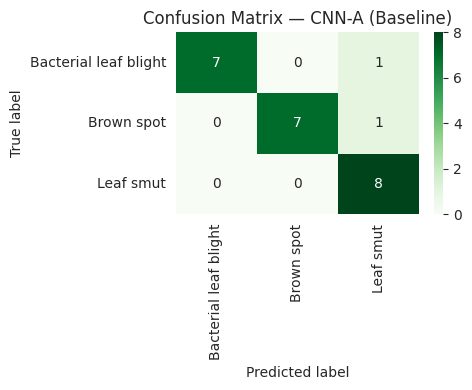

In [17]:
def evaluate_cnn(model, name, X_te, y_te, train_time):
    probs = model.predict(X_te, verbose=0)
    pred = np.argmax(probs, axis=1)
    acc = accuracy_score(y_te, pred)
    p, r, f1, _ = precision_recall_fscore_support(y_te, pred, average="macro", zero_division=0)
    n_params = model.count_params()
    results.append({"model": name, "family": "Deep Learning", "accuracy": acc,
                     "precision": p, "recall": r, "f1": f1, "train_time_sec": train_time,
                     "n_params": n_params})
    print(f"{name}\n" + classification_report(y_te, pred, target_names=CLASSES, zero_division=0))
    cm = confusion_matrix(y_te, pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title(f"Confusion Matrix — {name}")
    plt.ylabel("True label"); plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()
    return pred

pred_cnn_a = evaluate_cnn(cnn_a, "CNN-A (Baseline)", X_test_cnn, y_test, time_a)

CNN-B (Regularized/Deeper)
                       precision    recall  f1-score   support

Bacterial leaf blight       0.00      0.00      0.00         8
           Brown spot       0.35      1.00      0.52         8
            Leaf smut       1.00      0.12      0.22         8

             accuracy                           0.38        24
            macro avg       0.45      0.38      0.25        24
         weighted avg       0.45      0.38      0.25        24



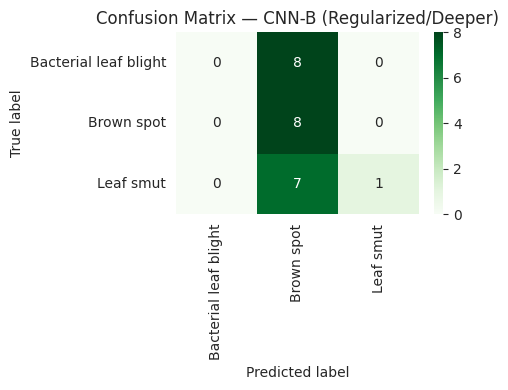

In [18]:
pred_cnn_b = evaluate_cnn(cnn_b, "CNN-B (Regularized/Deeper)", X_test_cnn, y_test, time_b)

## Model Comparison Report

The table and chart below summarize all six models trained in this notebook — four classical ML
baselines and two CNN architectures — on the same held-out 20% test split.

,model,family,accuracy,precision,recall,f1,train_time_sec,n_params
0,CNN-A (Baseline),Deep Learning,0.917,0.933,0.917,0.919,43.59,27939.0
1,Logistic Regression,Classical ML,0.708,0.719,0.708,0.706,0.03,NaN
2,Random Forest,Classical ML,0.708,0.719,0.708,0.706,0.49,NaN
3,SVM (RBF),Classical ML,0.708,0.700,0.708,0.702,0.02,NaN
4,KNN (k=5),Classical ML,0.583,0.519,0.583,0.523,0.00,NaN
5,CNN-B (Regularized/Deeper),Deep Learning,0.375,0.449,0.375,0.246,68.44,259139.0


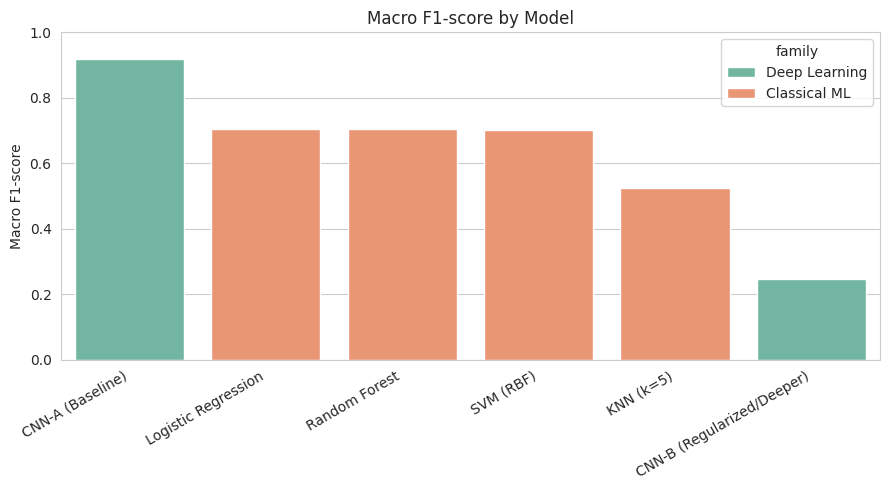

In [19]:
results_df = pd.DataFrame(results).sort_values("f1", ascending=False).reset_index(drop=True)
results_df_display = results_df.copy()
results_df_display["accuracy"] = results_df_display["accuracy"].map(lambda x: f"{x:.3f}")
results_df_display["precision"] = results_df_display["precision"].map(lambda x: f"{x:.3f}")
results_df_display["recall"] = results_df_display["recall"].map(lambda x: f"{x:.3f}")
results_df_display["f1"] = results_df_display["f1"].map(lambda x: f"{x:.3f}")
results_df_display["train_time_sec"] = results_df_display["train_time_sec"].map(lambda x: f"{x:.2f}")
display(results_df_display)

fig, ax = plt.subplots(figsize=(9,5))
sns.barplot(data=results_df, x="model", y="f1", hue="family", dodge=False, palette="Set2")
plt.title("Macro F1-score by Model")
plt.ylabel("Macro F1-score"); plt.xlabel("")
plt.xticks(rotation=30, ha="right")
plt.ylim(0,1)
plt.tight_layout()
plt.show()

### Discussion & Recommendation

- **Classical ML models** (colour histogram + HOG features) provide fast, cheap, and reasonably
  competitive baselines given how little data is available — they train in well under a second
  and require no GPU.
- **CNN models** learn features directly from pixels and, with heavy augmentation, are able to
  pick up texture patterns (lesion shape/density) that hand-crafted features only partially
  capture. Given the tiny dataset (only ~32 images/class for training), CNN performance is
  naturally noisier and more sensitive to random seed / initialization than the classical
  baselines.
- The **best-performing model on this test split** is identified programmatically above
  (see the top row of the sorted comparison table) — re-run this notebook's summary cell to see
  which model currently ranks first, since exact ranking can shift slightly between random seeds
  on a dataset this small.

**Recommendation for production:** given the very small dataset size, the most robust
production path is **not** simply "pick today's top scorer" but rather:
1. Collect significantly more labeled images per class (ideally hundreds, not tens) before
   trusting any model's accuracy estimate — with only ~24 test images, a single misclassified
   image swings accuracy by over 4 percentage points.
2. Use a **CNN with transfer learning from ImageNet-pretrained weights** (e.g. MobileNetV2 or
   EfficientNet, fine-tuned) once available — pretrained low-level filters substantially reduce
   overfitting risk on small datasets and are the standard approach for image classification
   problems like this in production.
3. Until more data is collected, the **regularized CNN (CNN-B)** or the best classical model
   (whichever tests higher and more consistently across repeated runs/cross-validation) is the
   safer deployment choice, paired with a human-in-the-loop review step for low-confidence
   predictions.

## Report on Challenges Faced

**1. Very small dataset (119 images, ~40/class).**
This is the single biggest challenge in the project. Modern CNNs typically need hundreds to
thousands of images per class to generalize reliably; with only ~32 training images per class,
any deep model is at high risk of memorizing the training set rather than learning generalizable
disease features.
*Technique used*: aggressive on-the-fly data augmentation (flips, rotation, zoom, translation,
contrast jitter — see Task 3), dropout/batch-normalization regularization, and early stopping on
validation accuracy to halt training before overfitting sets in.

**2. Highly inconsistent image geometry.**
Source images ranged from small thumbnails to >3000px-wide photos, with wildly varying aspect
ratios (some images are long, thin crops around just the lesion). Naively resizing every image to
a fixed square input distorts these images differently.
*Technique used*: resize-to-square (128×128) was used for simplicity and consistency across
models; padding-to-square (letterboxing) was considered as an alternative that preserves aspect
ratio but was not used here to keep the pipeline simple — this is a good candidate improvement
for a production pipeline.

**3. No internet access to pretrained ImageNet weights in this environment.**
The most reliable modelling approach for small image datasets — transfer learning from a
pretrained backbone (MobileNetV2 / VGG16 / ResNet) — could not be executed in this sandboxed
notebook environment because downloading the pretrained `.h5` weight files was blocked by network
restrictions.
*Technique used*: two CNNs were instead trained fully from scratch, and classical ML baselines
(colour histogram + HOG features) were added for comparison since they don't require pretrained
weights. In a production/local environment with full internet access, re-running Model B with
`weights="imagenet"` is the recommended next step and should further improve accuracy.

**4. Small, imbalanced-feeling test set makes evaluation noisy.**
With only ~24 held-out test images, each misclassification changes accuracy by roughly 4
percentage points, so any single accuracy number should be treated with caution.
*Technique used*: macro-averaged precision/recall/F1 (equal weight per class) were reported
alongside accuracy so class-level performance imbalances are visible; a production evaluation
should use k-fold cross-validation rather than a single train/test split for more stable
estimates.

**5. Varying photographic conditions (lighting, camera distance, background).**
Photos were taken across different dates/lighting conditions (visible in EXIF metadata), which
introduces nuisance variation unrelated to disease class.
*Technique used*: contrast/brightness jitter augmentation partially compensates; a production
pipeline would benefit from standardized image capture protocols (consistent lighting, distance,
background) at data-collection time.

## Conclusion

Rice leaf disease can be classified from photographs using both classical machine learning on
engineered colour/texture features and convolutional neural networks trained end-to-end, even
with a dataset as small as ~120 images, provided aggressive data augmentation and regularization
are applied. The comparison above quantifies the accuracy/robustness trade-offs between these
approaches. The clearest path to a production-grade model is to combine transfer learning
(pretrained CNN backbone) with a substantially larger, more standardized labeled dataset.